In [2]:
import pandas as pd
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(os.path.dirname(os.getcwd()))

# 读取数据
df = pd.read_csv("input/ukb/ukb_covreg1_trans1_nanf1_biom0.csv")

# 目标变量y和特征矩阵X
y = df['stage'].values
X = df.iloc[:, 7:].values  # 假设特征从第8列开始


In [ ]:
# 初始化 Lasso 回归模型，并设定正则化参数 alpha
lasso_cv = LassoCV(cv=5, n_alphas=100, n_jobs=-1, selection='random')

lasso_cv.fit(X, y)
optimal_alpha = lasso_cv.alpha_ 
print("最优的 alpha 参数:", optimal_alpha)

In [4]:
lasso = Lasso(alpha=optimal_alpha, selection='random')
lasso.fit(X, y)

Lasso(alpha=0.01174388887841015, selection='random')

In [5]:
y_pred = lasso.predict(X)
df['stage_pred'] = y_pred
df['age_gap'] = df['stage_pred'] - df['stage']
df[['RID', 'stage', 'stage_pred', 'age_gap']].to_csv("output/survival_analysis/ukb_MixtureGRBF_cv_nsubtype_biom17/5_subtypes/all_protein_stage_pred.csv", index=False)

In [6]:
from joblib import Parallel, delayed

# 计算每个特征的绝对值系数并排序
coef_abs = np.abs(lasso.coef_)
sorted_indices = np.argsort(coef_abs)  # 排序后的特征索引

# 用于保存每次删除特征后的 MSE
mse_values = []

# 初始预测的 MSE（使用所有特征）
y_pred_all = lasso.predict(X)
mse_values.append(mean_squared_error(y, y_pred_all))

# 定义并行计算 MSE 的函数
def compute_mse(i):
    # 删除最小系数对应的特征
    remaining_indices = sorted_indices[i-1:]  # 保留剩余特征
    X_selected = X[:, remaining_indices]  # 只保留剩余特征

    # 使用已有的系数进行预测
    y_pred_selected = np.dot(X_selected, lasso.coef_[remaining_indices]) + lasso.intercept_

    # 计算 MSE
    mse = mean_squared_error(y, y_pred_selected)
    return mse

# 使用 joblib 并行化 MSE 计算
mse_values_parallel = [mse_values[0]] + Parallel(n_jobs=-1)(delayed(compute_mse)(i) for i in range(1, X.shape[1] + 1))
mse_values_parallel.reverse()

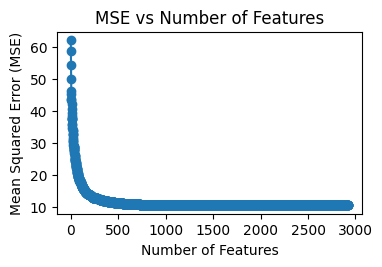

In [5]:
# 绘制 MSE 曲线
plt.figure(figsize=(10/2.54,6/2.54))
plt.plot(np.arange(len(mse_values_parallel)), mse_values_parallel, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Number of Features')
plt.savefig('tmp.png', dpi=300, bbox_inches='tight')
plt.show()

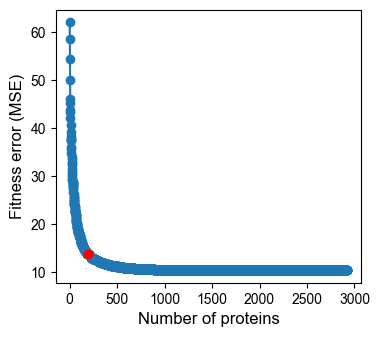

In [7]:
x = np.arange(len(mse_values_parallel))
y = mse_values_parallel


def second_derivative(x, y, delta=1):
    return (y[x+delta] - 2*y[x] + y[x-delta]) / delta**2

delta = 30

second_derivative_values = [second_derivative(i, y, delta) for i in range(delta, len(y)-delta)]

x_opt = np.argmin(second_derivative_values) + delta

plt.rcParams.update({
    'font.family': 'sans-serif',  # 指定字体家族为无衬线
    'font.sans-serif': ['Arial'], # 在无衬线字体列表中首选 Arial
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 8
})


plt.figure(figsize=(10/2.54,9/2.54))
plt.plot(x, y, marker='o')
plt.scatter(x_opt, y[x_opt], color='red', zorder=3)
plt.xlabel('Number of proteins')
plt.ylabel('Fitness error (MSE)')
plt.savefig('tmp.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print(x_opt)

197


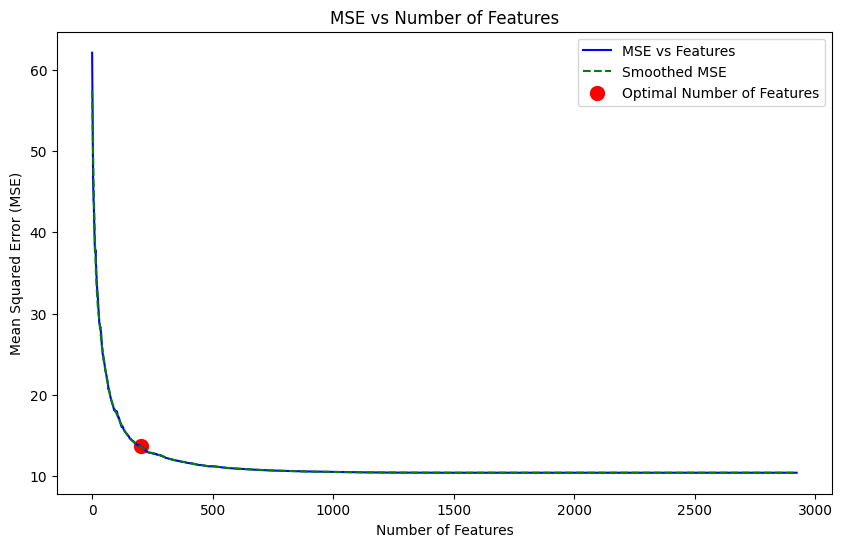

The optimal number of features (based on second derivative) is: 202


In [42]:
from scipy.signal import savgol_filter

# x 是特征数量，y 是 MSE 值
x = np.arange(len(mse_values_parallel))
y = mse_values_parallel

# Step 1: 使用 Savitzky-Golay 滤波器进行平滑和导数计算
# window_length 必须为奇数，polyorder 是拟合多项式的阶数
window_length = 53  # 可调整，窗口大小
polyorder = 3  # 多项式阶数

# 平滑处理（去噪）
smoothed_y = savgol_filter(y, window_length=window_length, polyorder=polyorder)

# 计算一阶导数
dy_dx = savgol_filter(smoothed_y, window_length=window_length, polyorder=polyorder, deriv=1)

# 计算二阶导数
d2y_dx2 = savgol_filter(smoothed_y, window_length=window_length, polyorder=polyorder, deriv=2)

# Step 2: 找到二阶导数最小的点（即拐点或极值点）
min_index = np.argmin(d2y_dx2)

# Step 3: 可视化结果
plt.figure(figsize=(10, 6))
# plt.plot(x, y, marker='o', label='MSE vs Features', color='b')
plt.plot(x, y, label='MSE vs Features', color='b')
plt.plot(x, smoothed_y, label='Smoothed MSE', color='g', linestyle='--')  # 绘制平滑后的曲线
plt.scatter(x[min_index], y[min_index], color='red', s=100, label='Optimal Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Number of Features')
plt.legend()
plt.show()

# Step 4: 打印最小二阶导数对应的 x 值（即最优特征数量）
print(f"The optimal number of features (based on second derivative) is: {x[min_index]}")

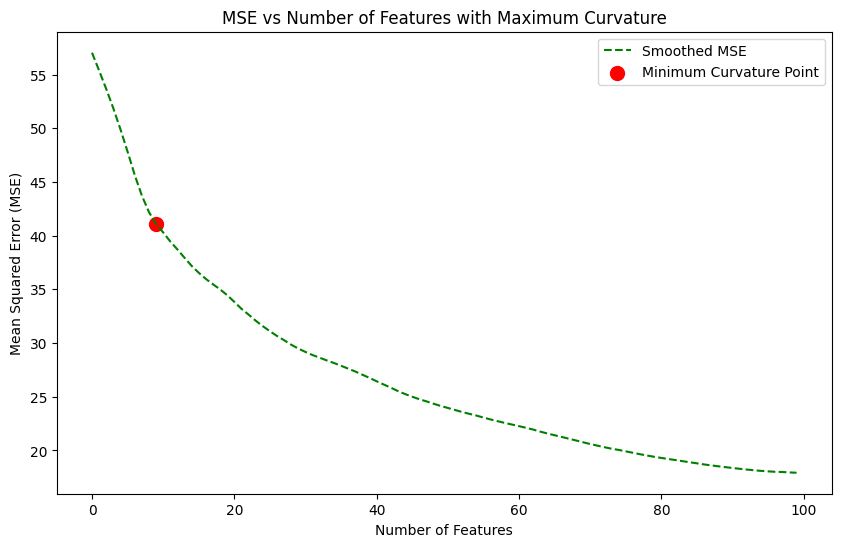

The optimal number of features (based on maximum curvature) is: 9


In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 假设 mse_values_parallel 已经定义
# x 是特征数量，y 是 MSE 值
x = np.arange(len(mse_values_parallel))
y = mse_values_parallel

# Step 1: 使用均值滤波器进行平滑处理
window_length = 11  # 可调整，窗口大小

# 创建一个均值滤波器
window = np.ones(window_length) / window_length

# 对 MSE 值进行卷积计算，得到平滑后的结果
# 使用 'valid'，并手动填充数组的边缘
pad_width = window_length // 2  # 填充宽度，窗口大小的一半

# 对原始数据进行前后填充
y_padded = np.pad(y, pad_width, mode='edge')

# 使用卷积（'valid' 模式）
smoothed_y = np.convolve(y_padded, window, mode='valid')

# Step 2: 计算一阶和二阶导数（数值求导）
dy_dx = np.gradient(smoothed_y, edge_order=2)
d2y_dx2 = np.gradient(dy_dx, edge_order=2)

# Step 3: 计算曲率
curvature = np.abs(d2y_dx2) / (1 + dy_dx**2)**(3/2)

# Step 4: 找到曲率最小的点
min_curvature_index = np.argmax(curvature)

# Step 5: 可视化结果
plt.figure(figsize=(10, 6))
plt.plot(x[:100], smoothed_y[:100], label='Smoothed MSE', color='g', linestyle='--')  # 绘制平滑后的曲线
plt.scatter(x[min_curvature_index], smoothed_y[min_curvature_index], color='red', s=100, label='Minimum Curvature Point')
plt.xlabel('Number of Features')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Number of Features with Maximum Curvature')
plt.legend()
plt.show()

# Step 6: 打印曲率最小点对应的 x 值（即曲率半径最小的特征数量）
print(f"The optimal number of features (based on maximum curvature) is: {x[min_curvature_index]}")


In [63]:
df.iloc[:, 7:].columns[sorted_indices[-x_opt:]].tolist().sort()  # 最优特征

with open('preprocess/significant_biomarker/biom17.txt', 'w') as f:
    f.write('\n'.join(sorted(df.iloc[:, 7:].columns[sorted_indices[-x_opt:]].tolist())))

